# 6. Visualize the data using Python libraries matplotlib, seaborn by plotting the graphs for Heart disease dataset.( Charts : Line chart, Barplot, Heatmap, Scatterplot, histogram, boxplot, violin, timeseries chart)

In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [152]:
df = pd.read_csv("heart.csv")

In [153]:
df

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [154]:
df = df.drop_duplicates()

In [155]:
df.shape

(302, 14)

In [156]:
df.isna().sum()
# No null values, it's clean

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

In [157]:
df.columns

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output'],
      dtype='str')

# Line Chart

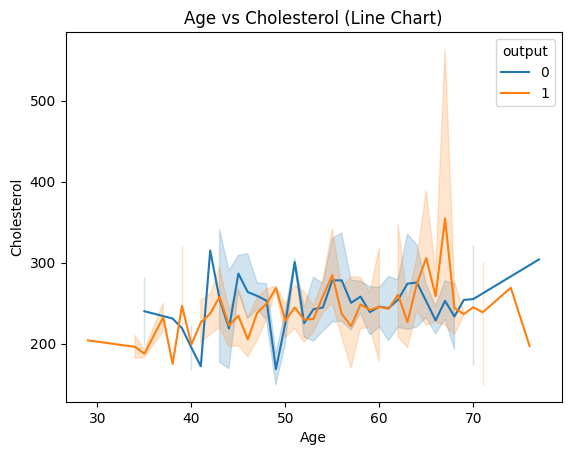

In [173]:
# Trends between age and cholesterol.
plt.figure()
sns.lineplot(data=df,x=df.age,y=df.chol,hue='output')
plt.title("Age vs Cholesterol (Line Chart)")
plt.xlabel("Age")
plt.ylabel("Cholesterol")
plt.show()

- The line chart shows how cholesterol levels vary with age, indicating slight fluctuations with no strong linear trend between age and cholesterol

# Bar Plot

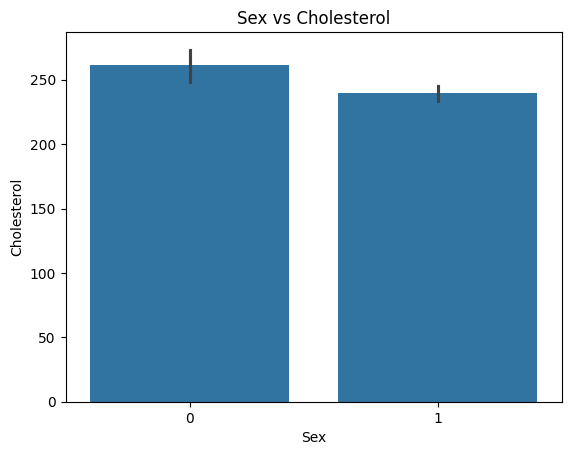

In [175]:
# Compares values between different categories.
plt.figure()
sns.barplot(x='sex', y='chol', data=df)
plt.title("Sex vs Cholesterol")
plt.xlabel("Sex")
plt.ylabel("Cholesterol")
plt.show()

- The bar plot shows that average cholesterol levels are slightly higher in females (0) compared to males (1).

# Heatmap

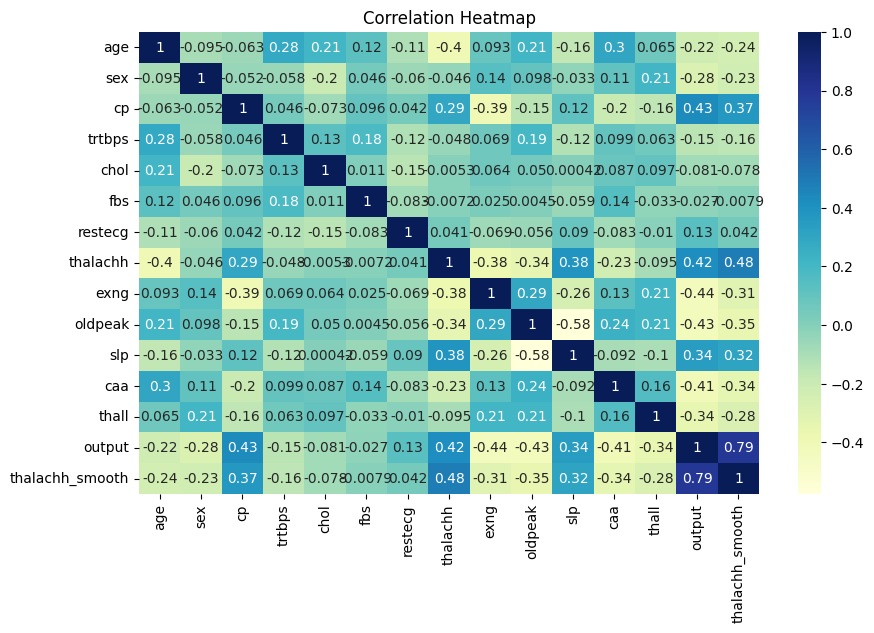

In [176]:
# Displays correlation between variables using colors.
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),cmap = 'YlGnBu', annot = True)
plt.title("Correlation Heatmap")
plt.show()

- The heatmap shows correlations between variables, where features like cp, thalachh, and oldpeak show stronger relationships with heart disease (output).

# Scatter Plot

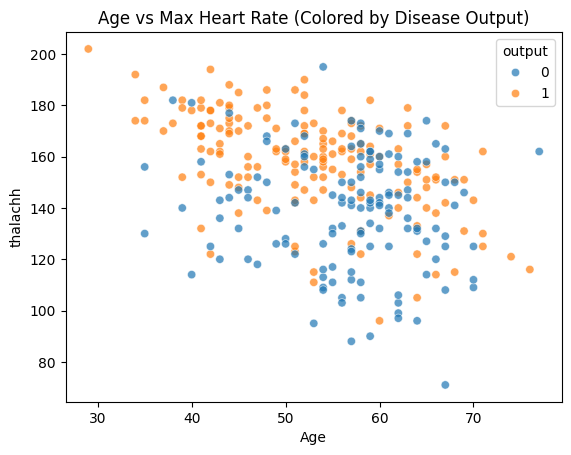

In [177]:
# Visualize relationship between age and maximum heart rate (thalachh).
plt.figure()
sns.scatterplot(x='age', y='thalachh', hue='output', data=df, alpha=0.7)
plt.title("Age vs Max Heart Rate (Colored by Disease Output)")
plt.xlabel("Age")
plt.ylabel("thalachh")
plt.show()

- The scatter plot shows a negative trend where maximum heart rate tends to decrease with increasing age, with some variation between disease and non-disease cases

# Histogram

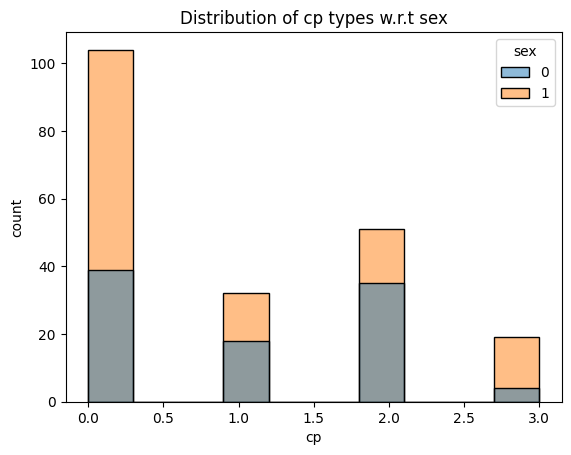

In [178]:
# Shows the Distribution of cp(Chest Pain) types with respect to male and female
plt.figure()
sns.histplot(data=df, x='cp', hue='sex')
plt.title("Distribution of cp types w.r.t sex")
plt.xlabel("cp")
plt.ylabel("count")
plt.show()

- The histogram shows that chest pain type 0 is most common, and males have higher frequency across all chest pain categories compared to females.

# Box Plot

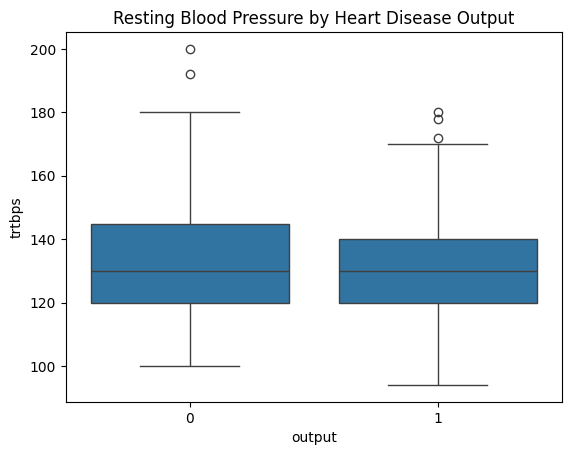

In [179]:
# Check spread and outliers in resting blood pressure (trtbps).
plt.figure()
sns.boxplot(x='output', y='trtbps', data=df)
plt.title("Resting Blood Pressure by Heart Disease Output")
plt.xlabel("output")
plt.ylabel("trtbps")
plt.show()

- The box plot shows similar median blood pressure for both groups, but highlights the presence of outliers in resting blood pressure

# Violin Plot

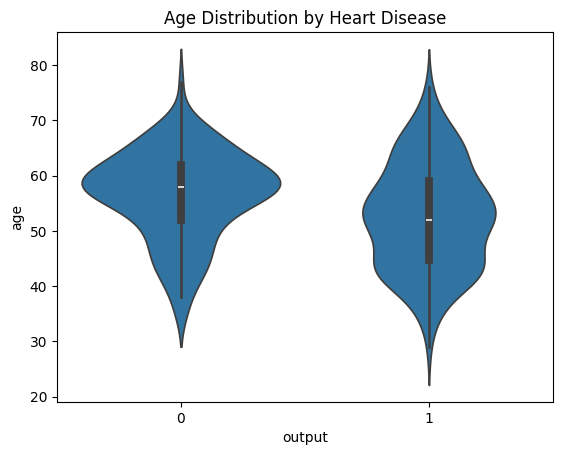

In [180]:
# Shows data distribution along with its density.
plt.figure()
sns.violinplot(x='output', y='age', data=df)
plt.title("Age Distribution by Heart Disease")
plt.xlabel("output")
plt.ylabel("age")
plt.show()

- The violin plot shows that age distribution is slightly higher for patients with heart disease, indicating increased risk with age

# Time Series Chart

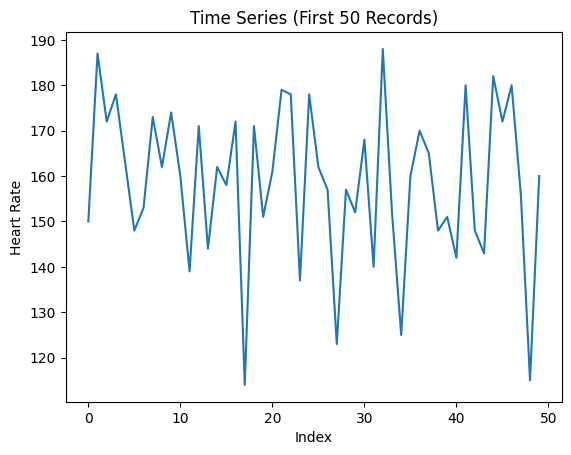

In [182]:
# how heart rate (thalachh) varies overtime across the first 50 observations
df_small = df.iloc[:50]   # first 50 rows

plt.figure()
plt.plot(df_small.index, df_small['thalachh'])
plt.title("Time Series (First 50 Records)")
plt.xlabel("Index")
plt.ylabel("Heart Rate")
plt.show()

- The time series plot shows fluctuations in heart rate across observations, with no clear increasing or decreasing trend

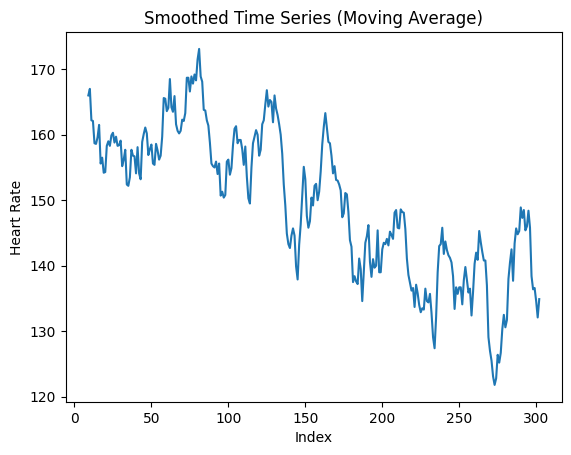

In [183]:
# Create a new column, Takes 10 consecutive values at a time, Calculates the average of those 10 values
df['thalachh_smooth'] = df['thalachh'].rolling(window=10).mean()

plt.figure()
plt.plot(df.index, df['thalachh_smooth'])
plt.title("Smoothed Time Series (Moving Average)")
plt.xlabel("Index")
plt.ylabel("Heart Rate")
plt.show()